EXPERIMENT 8
COMPARATIVE ANALYSIS OF SARSA AND Q-LEARNING

AIM
---------------------------------------------------------------------------
To implement and compare SARSA and Q-Learning algorithms
for solving a Reinforcement Learning environment.

THEORY
---------------------------------------------------------------------------
SARSA is an on-policy Temporal Difference algorithm.
Q-Learning is an off-policy Temporal Difference algorithm.

SARSA Equation:
Q(S,A) = Q(S,A) + alpha * [R + gamma*Q(S',A') - Q(S,A)]

Q-Learning Equation:
Q(S,A) = Q(S,A) + alpha * [R + gamma*max(Q(S',A')) - Q(S,A)]

SARSA Training Completed.
SARSA Execution Time : 0.03991 seconds


Q-LEARNING TRAINING COMPLETED
Q-Learning Execution Time : 0.06565 seconds


FINAL SARSA Q-TABLE
        Left   Right
Start  4.549   6.669
S1     4.356   7.780
S2     4.866   8.932
S3     6.404  10.000
Goal   0.000   0.000


FINAL Q-LEARNING Q-TABLE
        Left  Right
Start  5.561   7.29
S1     5.561   8.10
S2     6.290   9.00
S3   

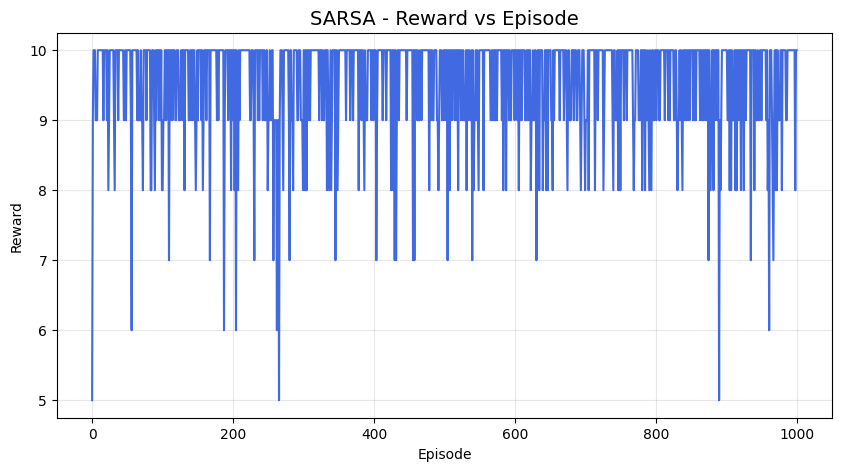

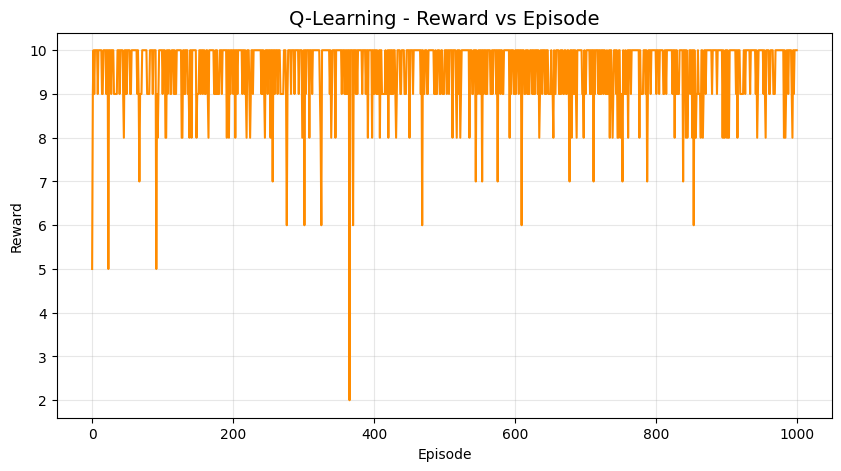

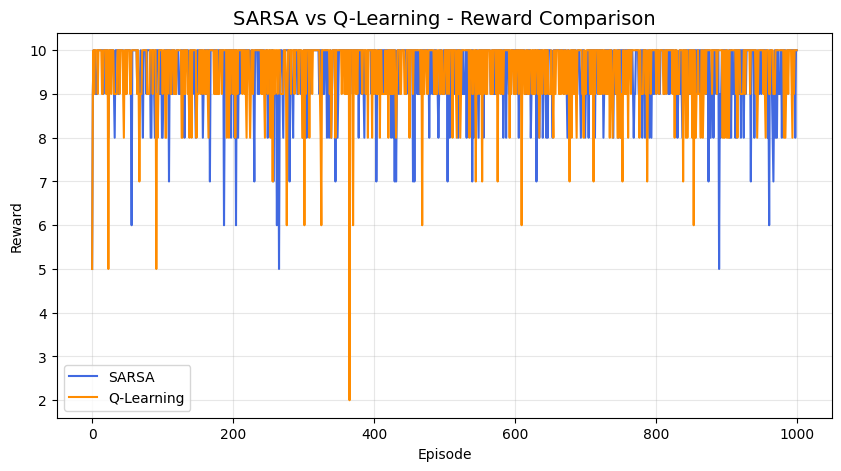

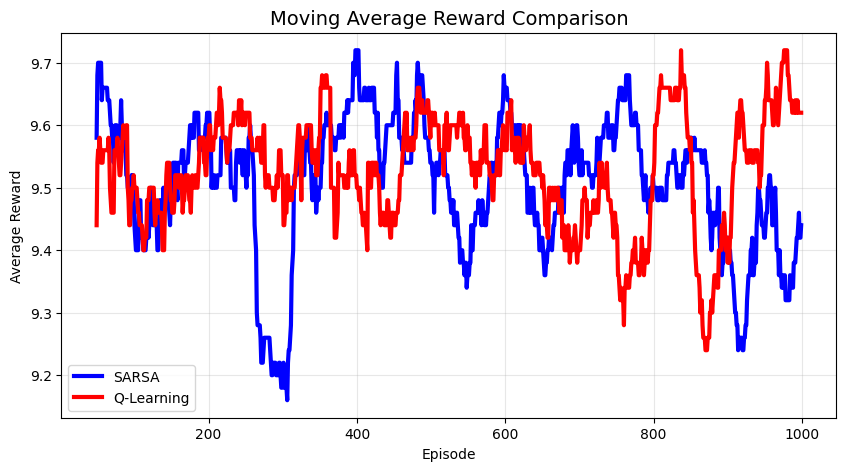

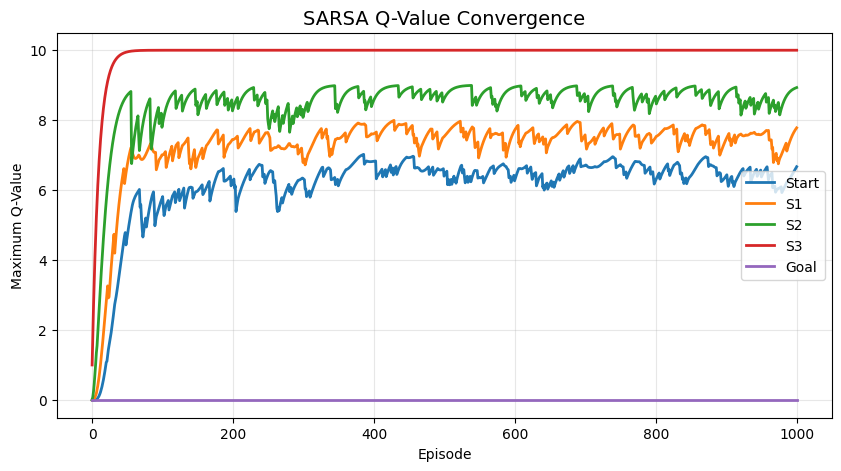

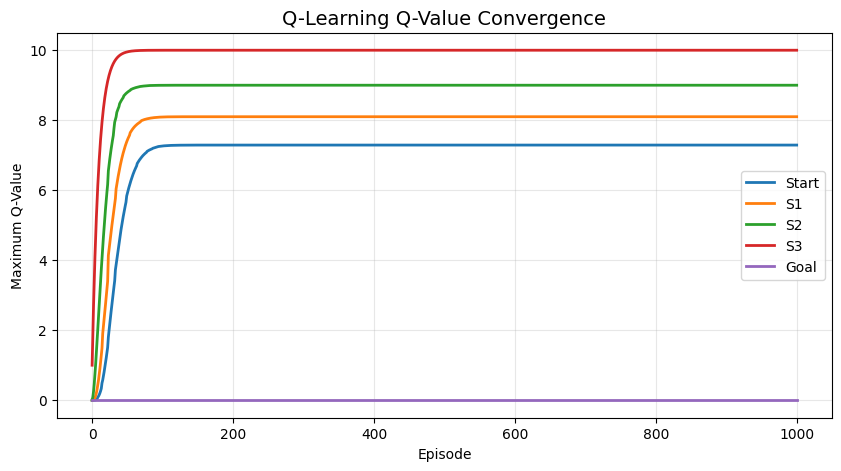

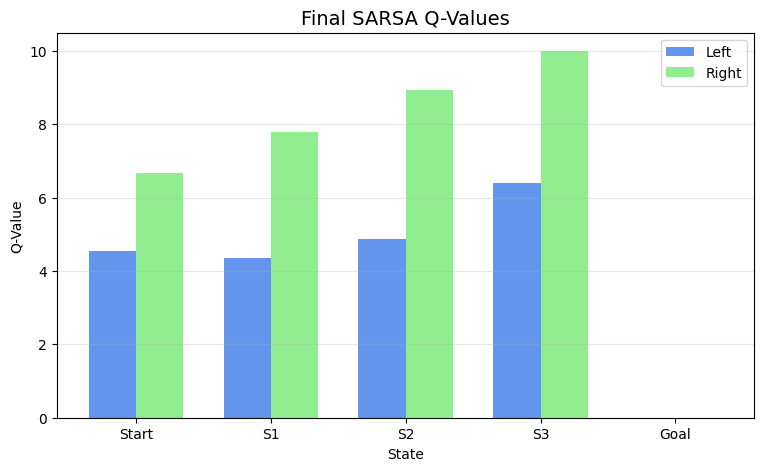

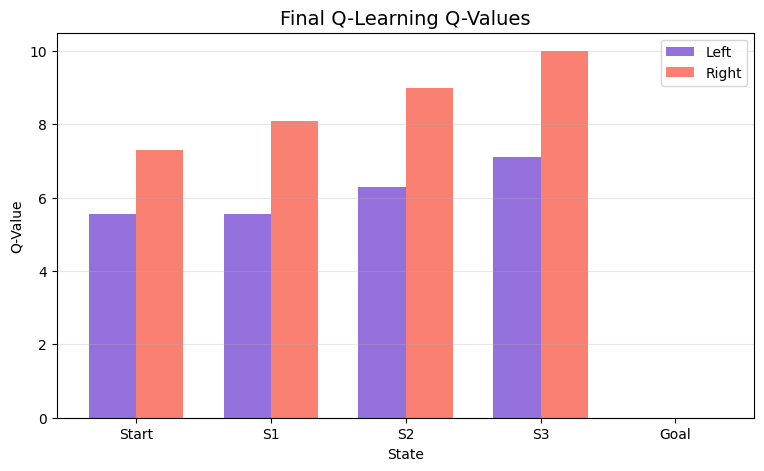

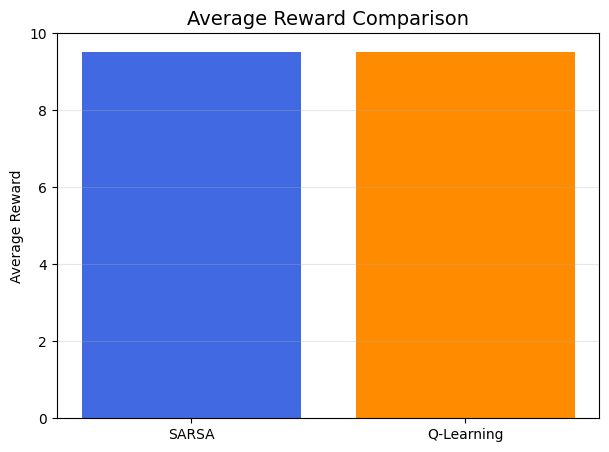

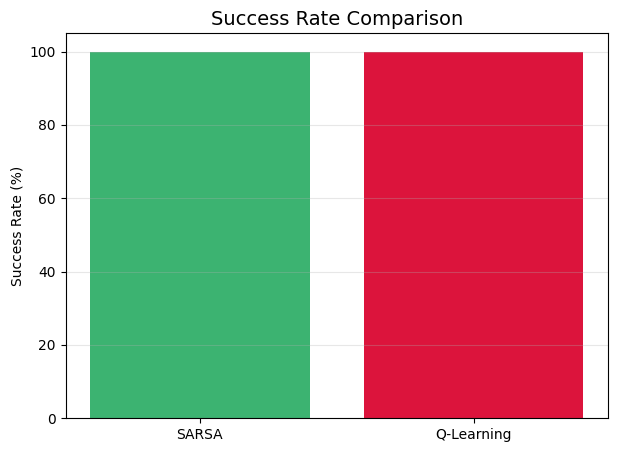



FINAL PERFORMANCE COMPARISON
                   Metric      SARSA  Q-Learning
                 Episodes 1000.00000  1000.00000
    Learning Rate (Alpha)    0.10000     0.10000
  Discount Factor (Gamma)    0.90000     0.90000
                  Epsilon    0.20000     0.20000
           Average Reward    9.50800     9.52600
  Last 100 Episode Reward    9.43000     9.61000
         Success Rate (%)  100.00000   100.00000
            Average Steps    4.85000     4.84000
   Last 100 Episode Steps    5.02000     4.64000
Average Absolute TD Error    0.59710     0.12500
           Final TD Error    0.35530     0.00000
 Execution Time (seconds)    0.03991     0.06565


FINAL POLICY AND Q-VALUE TABLE
State  SARSA Left Q  SARSA Right Q SARSA Optimal Action  Q-Learning Left Q  Q-Learning Right Q Q-Learning Optimal Action
Start         4.549          6.669                Right              5.561                7.29                     Right
   S1         4.356          7.780                Right  

In [1]:
# ================================================================
# EXPERIMENT 8
# Comparative Analysis of SARSA and Q-Learning
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time

print("=" * 75)
print("EXPERIMENT 8")
print("COMPARATIVE ANALYSIS OF SARSA AND Q-LEARNING")
print("=" * 75)

# ================================================================
# AIM
# ================================================================

print("\nAIM")
print("-" * 75)

print(
    "To implement and compare SARSA and Q-Learning algorithms"
)

print(
    "for solving a Reinforcement Learning environment."
)

# ================================================================
# THEORY
# ================================================================

print("\nTHEORY")
print("-" * 75)

print("SARSA is an on-policy Temporal Difference algorithm.")

print("Q-Learning is an off-policy Temporal Difference algorithm.")

print("\nSARSA Equation:")

print(
    "Q(S,A) = Q(S,A) + alpha * "
    "[R + gamma*Q(S',A') - Q(S,A)]"
)

print("\nQ-Learning Equation:")

print(
    "Q(S,A) = Q(S,A) + alpha * "
    "[R + gamma*max(Q(S',A')) - Q(S,A)]"
)

# ================================================================
# ENVIRONMENT
# ================================================================

states = [
    "Start",
    "S1",
    "S2",
    "S3",
    "Goal"
]

actions = [
    "Left",
    "Right"
]

n_states = len(states)
n_actions = len(actions)

# ================================================================
# PARAMETERS
# ================================================================

alpha = 0.10
gamma = 0.90
epsilon = 0.20

episodes = 1000
max_steps = 20

# ================================================================
# ENVIRONMENT TRANSITION
# ================================================================

def get_next_state(state, action):

    if state == 0:

        if action == 0:
            return 0, -1

        return 1, 0

    elif state == 1:

        if action == 0:
            return 0, -1

        return 2, 0

    elif state == 2:

        if action == 0:
            return 1, -1

        return 3, 0

    elif state == 3:

        if action == 0:
            return 2, -1

        return 4, 10

    else:

        return 4, 0


# ================================================================
# EPSILON-GREEDY ACTION
# ================================================================

def choose_action(q_table, state):

    if random.random() < epsilon:

        return random.randint(
            0,
            n_actions - 1
        )

    return int(
        np.argmax(q_table[state])
    )


# ================================================================
# INITIALIZE Q-TABLES
# ================================================================

Q_sarsa = np.zeros(
    (n_states, n_actions)
)

Q_qlearning = np.zeros(
    (n_states, n_actions)
)

# ================================================================
# STATISTICS
# ================================================================

sarsa_rewards = []
qlearning_rewards = []

sarsa_steps = []
qlearning_steps = []

sarsa_success = []
qlearning_success = []

sarsa_td_errors = []
qlearning_td_errors = []

sarsa_value_history = []
qlearning_value_history = []

sarsa_start = time.time()

# ================================================================
# SARSA TRAINING
# ================================================================

for episode in range(episodes):

    state = 0

    action = choose_action(
        Q_sarsa,
        state
    )

    total_reward = 0
    steps = 0
    success = 0

    for step in range(max_steps):

        steps += 1

        next_state, reward = get_next_state(
            state,
            action
        )

        # Choose NEXT action using current policy

        next_action = choose_action(
            Q_sarsa,
            next_state
        )

        # --------------------------------------------------------
        # SARSA TD Target
        # --------------------------------------------------------

        td_target = (
            reward
            + gamma * Q_sarsa[
                next_state,
                next_action
            ]
        )

        # --------------------------------------------------------
        # SARSA TD Error
        # --------------------------------------------------------

        td_error = (
            td_target
            - Q_sarsa[state, action]
        )

        # --------------------------------------------------------
        # SARSA Update
        # --------------------------------------------------------

        Q_sarsa[state, action] += (
            alpha * td_error
        )

        sarsa_td_errors.append(
            td_error
        )

        total_reward += reward

        state = next_state

        action = next_action

        if state == 4:

            success = 1

            break

    sarsa_rewards.append(
        total_reward
    )

    sarsa_steps.append(
        steps
    )

    sarsa_success.append(
        success
    )

    sarsa_value_history.append(
        Q_sarsa.copy()
    )

sarsa_time = time.time() - sarsa_start

print("\nSARSA Training Completed.")

print(
    "SARSA Execution Time :",
    round(sarsa_time, 5),
    "seconds"
)
# ================================================================
# Q-LEARNING TRAINING
# ================================================================

qlearning_start = time.time()

for episode in range(episodes):

    state = 0

    total_reward = 0
    steps = 0
    success = 0

    for step in range(max_steps):

        steps += 1

        # --------------------------------------------------------
        # Choose action using epsilon-greedy policy
        # --------------------------------------------------------

        action = choose_action(
            Q_qlearning,
            state
        )

        # --------------------------------------------------------
        # Take action
        # --------------------------------------------------------

        next_state, reward = get_next_state(
            state,
            action
        )

        # --------------------------------------------------------
        # Q-Learning TD Target
        #
        # Q-Learning is OFF-POLICY.
        # It uses the maximum Q-value of the next state.
        # --------------------------------------------------------

        if next_state == 4:

            td_target = reward

        else:

            td_target = (
                reward
                + gamma * np.max(
                    Q_qlearning[next_state]
                )
            )

        # --------------------------------------------------------
        # Q-Learning TD Error
        # --------------------------------------------------------

        td_error = (
            td_target
            - Q_qlearning[state, action]
        )

        # --------------------------------------------------------
        # Q-Learning Update
        # --------------------------------------------------------

        Q_qlearning[state, action] += (
            alpha * td_error
        )

        qlearning_td_errors.append(
            td_error
        )

        total_reward += reward

        state = next_state

        # --------------------------------------------------------
        # Goal reached
        # --------------------------------------------------------

        if state == 4:

            success = 1

            break

    qlearning_rewards.append(
        total_reward
    )

    qlearning_steps.append(
        steps
    )

    qlearning_success.append(
        success
    )

    qlearning_value_history.append(
        Q_qlearning.copy()
    )


qlearning_time = time.time() - qlearning_start


print("\n")
print("=" * 75)
print("Q-LEARNING TRAINING COMPLETED")
print("=" * 75)

print(
    "Q-Learning Execution Time :",
    round(qlearning_time, 5),
    "seconds"
)


# ================================================================
# FINAL Q-TABLES
# ================================================================

sarsa_q_table = pd.DataFrame(
    Q_sarsa,
    index=states,
    columns=actions
)

qlearning_q_table = pd.DataFrame(
    Q_qlearning,
    index=states,
    columns=actions
)

print("\n")
print("=" * 75)
print("FINAL SARSA Q-TABLE")
print("=" * 75)

print(
    sarsa_q_table.round(3)
)


print("\n")
print("=" * 75)
print("FINAL Q-LEARNING Q-TABLE")
print("=" * 75)

print(
    qlearning_q_table.round(3)
)


# ================================================================
# OPTIMAL POLICY FROM SARSA
# ================================================================

sarsa_policy = []

for state in range(n_states):

    if state == n_states - 1:

        sarsa_policy.append(
            "Terminal"
        )

    else:

        best_action = int(
            np.argmax(Q_sarsa[state])
        )

        sarsa_policy.append(
            actions[best_action]
        )


# ================================================================
# OPTIMAL POLICY FROM Q-LEARNING
# ================================================================

qlearning_policy = []

for state in range(n_states):

    if state == n_states - 1:

        qlearning_policy.append(
            "Terminal"
        )

    else:

        best_action = int(
            np.argmax(Q_qlearning[state])
        )

        qlearning_policy.append(
            actions[best_action]
        )


# ================================================================
# POLICY COMPARISON TABLE
# ================================================================

policy_comparison = pd.DataFrame({

    "State": states,

    "SARSA Policy": sarsa_policy,

    "Q-Learning Policy": qlearning_policy

})

print("\n")
print("=" * 75)
print("OPTIMAL POLICY COMPARISON")
print("=" * 75)

print(
    policy_comparison.to_string(
        index=False
    )
)


# ================================================================
# PERFORMANCE METRICS
# ================================================================

sarsa_average_reward = np.mean(
    sarsa_rewards
)

qlearning_average_reward = np.mean(
    qlearning_rewards
)

sarsa_success_rate = (
    np.mean(sarsa_success) * 100
)

qlearning_success_rate = (
    np.mean(qlearning_success) * 100
)

sarsa_average_steps = np.mean(
    sarsa_steps
)

qlearning_average_steps = np.mean(
    qlearning_steps
)

sarsa_average_td_error = np.mean(
    np.abs(sarsa_td_errors)
)

qlearning_average_td_error = np.mean(
    np.abs(qlearning_td_errors)
)


# ================================================================
# PERFORMANCE COMPARISON TABLE
# ================================================================

performance_comparison = pd.DataFrame({

    "Metric": [
        "Average Reward",
        "Success Rate (%)",
        "Average Steps",
        "Average Absolute TD Error",
        "Execution Time (seconds)"
    ],

    "SARSA": [
        round(
            sarsa_average_reward,
            3
        ),

        round(
            sarsa_success_rate,
            2
        ),

        round(
            sarsa_average_steps,
            2
        ),

        round(
            sarsa_average_td_error,
            4
        ),

        round(
            sarsa_time,
            5
        )
    ],

    "Q-Learning": [
        round(
            qlearning_average_reward,
            3
        ),

        round(
            qlearning_success_rate,
            2
        ),

        round(
            qlearning_average_steps,
            2
        ),

        round(
            qlearning_average_td_error,
            4
        ),

        round(
            qlearning_time,
            5
        )
    ]
})

print("\n")
print("=" * 75)
print("SARSA VS Q-LEARNING PERFORMANCE")
print("=" * 75)

print(
    performance_comparison.to_string(
        index=False
    )
)


# ================================================================
# SAVE BASIC RESULTS
# ================================================================

sarsa_q_table.to_csv(
    "SARSA_Q_Table.csv"
)

qlearning_q_table.to_csv(
    "QLearning_Q_Table.csv"
)

policy_comparison.to_csv(
    "SARSA_QLearning_Policy.csv",
    index=False
)

performance_comparison.to_csv(
    "SARSA_QLearning_Performance.csv",
    index=False
)
# ================================================================
# EXPERIMENT 8 - VISUALIZATIONS
# SARSA VS Q-LEARNING
# ================================================================

# Convert Q-value histories to arrays

sarsa_value_history = np.array(
    sarsa_value_history
)

qlearning_value_history = np.array(
    qlearning_value_history
)

# ================================================================
# GRAPH 1
# SARSA Reward vs Episode
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    sarsa_rewards,
    color="royalblue",
    linewidth=1.5
)

plt.title(
    "SARSA - Reward vs Episode",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 2
# Q-Learning Reward vs Episode
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    qlearning_rewards,
    color="darkorange",
    linewidth=1.5
)

plt.title(
    "Q-Learning - Reward vs Episode",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 3
# SARSA vs Q-Learning Reward
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    sarsa_rewards,
    label="SARSA",
    color="royalblue",
    linewidth=1.5
)

plt.plot(
    qlearning_rewards,
    label="Q-Learning",
    color="darkorange",
    linewidth=1.5
)

plt.title(
    "SARSA vs Q-Learning - Reward Comparison",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 4
# Moving Average Reward Comparison
# ================================================================

window = 50

sarsa_moving_average = (
    pd.Series(sarsa_rewards)
    .rolling(window)
    .mean()
)

qlearning_moving_average = (
    pd.Series(qlearning_rewards)
    .rolling(window)
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    sarsa_moving_average,
    label="SARSA",
    color="blue",
    linewidth=3
)

plt.plot(
    qlearning_moving_average,
    label="Q-Learning",
    color="red",
    linewidth=3
)

plt.title(
    "Moving Average Reward Comparison",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Average Reward")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 5
# SARSA Q-Value Convergence
# ================================================================

plt.figure(figsize=(10, 5))

for state_index in range(n_states):

    # Maximum Q-value for each state

    state_values = np.max(
        sarsa_value_history[:, state_index, :],
        axis=1
    )

    plt.plot(
        state_values,
        linewidth=2,
        label=states[state_index]
    )

plt.title(
    "SARSA Q-Value Convergence",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Maximum Q-Value")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 6
# Q-Learning Q-Value Convergence
# ================================================================

plt.figure(figsize=(10, 5))

for state_index in range(n_states):

    state_values = np.max(
        qlearning_value_history[
            :,
            state_index,
            :
        ],
        axis=1
    )

    plt.plot(
        state_values,
        linewidth=2,
        label=states[state_index]
    )

plt.title(
    "Q-Learning Q-Value Convergence",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Maximum Q-Value")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 7
# Final SARSA Q-Values
# ================================================================

x = np.arange(n_states)

width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    Q_sarsa[:, 0],
    width,
    label="Left",
    color="cornflowerblue"
)

plt.bar(
    x + width / 2,
    Q_sarsa[:, 1],
    width,
    label="Right",
    color="lightgreen"
)

plt.xticks(
    x,
    states
)

plt.title(
    "Final SARSA Q-Values",
    fontsize=14
)

plt.xlabel("State")

plt.ylabel("Q-Value")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ================================================================
# GRAPH 8
# Final Q-Learning Q-Values
# ================================================================

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    Q_qlearning[:, 0],
    width,
    label="Left",
    color="mediumpurple"
)

plt.bar(
    x + width / 2,
    Q_qlearning[:, 1],
    width,
    label="Right",
    color="salmon"
)

plt.xticks(
    x,
    states
)

plt.title(
    "Final Q-Learning Q-Values",
    fontsize=14
)

plt.xlabel("State")

plt.ylabel("Q-Value")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ================================================================
# GRAPH 9
# Average Reward Comparison
# ================================================================

plt.figure(figsize=(7, 5))

plt.bar(
    ["SARSA", "Q-Learning"],
    [
        sarsa_average_reward,
        qlearning_average_reward
    ],
    color=[
        "royalblue",
        "darkorange"
    ]
)

plt.title(
    "Average Reward Comparison",
    fontsize=14
)

plt.ylabel("Average Reward")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ================================================================
# GRAPH 10
# Success Rate Comparison
# ================================================================

plt.figure(figsize=(7, 5))

plt.bar(
    ["SARSA", "Q-Learning"],
    [
        sarsa_success_rate,
        qlearning_success_rate
    ],
    color=[
        "mediumseagreen",
        "crimson"
    ]
)

plt.title(
    "Success Rate Comparison",
    fontsize=14
)

plt.ylabel("Success Rate (%)")

plt.ylim(0, 105)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()
# ================================================================
# EXPERIMENT 8 - FINAL RESULTS
# SARSA VS Q-LEARNING
# ================================================================

# ================================================================
# FINAL TD ERROR ANALYSIS
# ================================================================

sarsa_final_td_error = np.mean(
    np.abs(sarsa_td_errors[-100:])
)

qlearning_final_td_error = np.mean(
    np.abs(qlearning_td_errors[-100:])
)

# ================================================================
# AVERAGE REWARD OF LAST 100 EPISODES
# ================================================================

sarsa_last_100_reward = np.mean(
    sarsa_rewards[-100:]
)

qlearning_last_100_reward = np.mean(
    qlearning_rewards[-100:]
)

# ================================================================
# AVERAGE STEPS OF LAST 100 EPISODES
# ================================================================

sarsa_last_100_steps = np.mean(
    sarsa_steps[-100:]
)

qlearning_last_100_steps = np.mean(
    qlearning_steps[-100:]
)

# ================================================================
# FINAL PERFORMANCE TABLE
# ================================================================

final_performance = pd.DataFrame({

    "Metric": [
        "Episodes",
        "Learning Rate (Alpha)",
        "Discount Factor (Gamma)",
        "Epsilon",
        "Average Reward",
        "Last 100 Episode Reward",
        "Success Rate (%)",
        "Average Steps",
        "Last 100 Episode Steps",
        "Average Absolute TD Error",
        "Final TD Error",
        "Execution Time (seconds)"
    ],

    "SARSA": [
        episodes,
        alpha,
        gamma,
        epsilon,
        round(sarsa_average_reward, 3),
        round(sarsa_last_100_reward, 3),
        round(sarsa_success_rate, 2),
        round(sarsa_average_steps, 2),
        round(sarsa_last_100_steps, 2),
        round(sarsa_average_td_error, 4),
        round(sarsa_final_td_error, 4),
        round(sarsa_time, 5)
    ],

    "Q-Learning": [
        episodes,
        alpha,
        gamma,
        epsilon,
        round(qlearning_average_reward, 3),
        round(qlearning_last_100_reward, 3),
        round(qlearning_success_rate, 2),
        round(qlearning_average_steps, 2),
        round(qlearning_last_100_steps, 2),
        round(qlearning_average_td_error, 4),
        round(qlearning_final_td_error, 4),
        round(qlearning_time, 5)
    ]
})

print("\n")
print("=" * 75)
print("FINAL PERFORMANCE COMPARISON")
print("=" * 75)

print(
    final_performance.to_string(
        index=False
    )
)

# ================================================================
# FINAL POLICY TABLE
# ================================================================

final_policy_table = pd.DataFrame({

    "State": states,

    "SARSA Left Q": np.round(
        Q_sarsa[:, 0],
        3
    ),

    "SARSA Right Q": np.round(
        Q_sarsa[:, 1],
        3
    ),

    "SARSA Optimal Action": sarsa_policy,

    "Q-Learning Left Q": np.round(
        Q_qlearning[:, 0],
        3
    ),

    "Q-Learning Right Q": np.round(
        Q_qlearning[:, 1],
        3
    ),

    "Q-Learning Optimal Action": qlearning_policy
})

print("\n")
print("=" * 75)
print("FINAL POLICY AND Q-VALUE TABLE")
print("=" * 75)

print(
    final_policy_table.to_string(
        index=False
    )
)

# ================================================================
# EXPLORATION / EXPLOITATION INFORMATION
# ================================================================

total_decisions = (
    episodes * max_steps
)

print("\n")
print("=" * 75)
print("EXPLORATION AND EXPLOITATION")
print("=" * 75)

print(
    "Epsilon :",
    epsilon
)

print(
    "Approximate Exploration Rate :",
    epsilon * 100,
    "%"
)

print(
    "Approximate Exploitation Rate :",
    (1 - epsilon) * 100,
    "%"
)

# ================================================================
# ALGORITHM WINNER
# ================================================================

if qlearning_average_reward > sarsa_average_reward:

    better_algorithm = "Q-Learning"

elif sarsa_average_reward > qlearning_average_reward:

    better_algorithm = "SARSA"

else:

    better_algorithm = "Both algorithms have equal average reward"

print("\n")
print("=" * 75)
print("ALGORITHM COMPARISON RESULT")
print("=" * 75)

print(
    "Higher Average Reward :",
    better_algorithm
)

print(
    "SARSA Average Reward :",
    round(sarsa_average_reward, 3)
)

print(
    "Q-Learning Average Reward :",
    round(qlearning_average_reward, 3)
)

# ================================================================
# SAVE CSV FILES
# ================================================================

final_performance.to_csv(
    "Experiment8_Performance.csv",
    index=False
)

final_policy_table.to_csv(
    "Experiment8_Final_Policy.csv",
    index=False
)

# ================================================================
# COMPLETE EPISODE SUMMARY
# ================================================================

episode_comparison = pd.DataFrame({

    "Episode": np.arange(
        1,
        episodes + 1
    ),

    "SARSA Reward": np.round(
        sarsa_rewards,
        3
    ),

    "Q-Learning Reward": np.round(
        qlearning_rewards,
        3
    ),

    "SARSA Steps": sarsa_steps,

    "Q-Learning Steps": qlearning_steps,

    "SARSA Success": sarsa_success,

    "Q-Learning Success": qlearning_success
})

episode_comparison.to_csv(
    "Experiment8_Episode_Comparison.csv",
    index=False
)

# ================================================================
# FINAL SUMMARY TABLE
# ================================================================

final_summary = pd.DataFrame({

    "Parameter": [
        "Algorithm Type",
        "Learning Method",
        "Episodes",
        "Alpha",
        "Gamma",
        "Epsilon",
        "Average Reward",
        "Success Rate",
        "Average Steps",
        "Final TD Error",
        "Execution Time"
    ],

    "SARSA": [
        "On-Policy",
        "TD Learning",
        episodes,
        alpha,
        gamma,
        epsilon,
        round(sarsa_average_reward, 3),
        str(round(sarsa_success_rate, 2)) + "%",
        round(sarsa_average_steps, 2),
        round(sarsa_final_td_error, 4),
        str(round(sarsa_time, 5)) + " sec"
    ],

    "Q-Learning": [
        "Off-Policy",
        "TD Learning",
        episodes,
        alpha,
        gamma,
        epsilon,
        round(qlearning_average_reward, 3),
        str(round(qlearning_success_rate, 2)) + "%",
        round(qlearning_average_steps, 2),
        round(qlearning_final_td_error, 4),
        str(round(qlearning_time, 5)) + " sec"
    ]
})

print("\n")
print("=" * 75)
print("COMPLETE SUMMARY TABLE")
print("=" * 75)

print(
    final_summary.to_string(
        index=False
    )
)

final_summary.to_csv(
    "Experiment8_Complete_Summary.csv",
    index=False
)

# ================================================================
# FINAL INTERPRETATION
# ================================================================

print("\n")
print("=" * 75)
print("INTERPRETATION")
print("=" * 75)

print(
    "1. SARSA is an on-policy TD learning algorithm."
)

print(
    "2. Q-Learning is an off-policy TD learning algorithm."
)

print(
    "3. SARSA updates Q-values using the next action"
)

print(
    "   actually selected by the current policy."
)

print(
    "4. Q-Learning updates Q-values using the maximum"
)

print(
    "   possible Q-value of the next state."
)

print(
    "5. Both algorithms learn an optimal or near-optimal"
)

print(
    "   action policy through repeated interaction."
)

# ================================================================
# CONCLUSION
# ================================================================

print("\n")
print("=" * 75)
print("CONCLUSION")
print("=" * 75)

print(
    "SARSA and Q-Learning were successfully implemented"
)

print(
    "and compared in a Reinforcement Learning environment."
)

print(
    "SARSA learned using an on-policy approach, while"
)

print(
    "Q-Learning used an off-policy approach."
)

print(
    "The reward, Q-value convergence, success rate,"
)

print(
    "TD error, episode length, and execution time were"
)

print(
    "used to compare their performance."
)

print(
    "The experiment demonstrates the practical difference"
)

print(
    "between on-policy SARSA and off-policy Q-Learning."
)

# ================================================================
# GENERATED FILES
# ================================================================

print("\n")
print("=" * 75)
print("FILES GENERATED")
print("=" * 75)

print("1. SARSA_Q_Table.csv")
print("2. QLearning_Q_Table.csv")
print("3. SARSA_QLearning_Policy.csv")
print("4. SARSA_QLearning_Performance.csv")
print("5. Experiment8_Performance.csv")
print("6. Experiment8_Final_Policy.csv")
print("7. Experiment8_Episode_Comparison.csv")
print("8. Experiment8_Complete_Summary.csv")

print("\n")
print("=" * 75)
print("EXPERIMENT 8 COMPLETED SUCCESSFULLY")
print("=" * 75)